# Hồi quy tuyến tính ( Linear Regression ) : Ứng dụng vào dự đoán chỉ số chất lượng không khí AQI

***"Không có một sự kiện nào trên đời là ngẫu nhiên, những thứ đang cho là ngẫu nhiên chỉ là những sự kiện ta chưa tìm ra được mô hình để biểu diễn quy luật của chúng".***

Trong bài tập này, nhóm xây dựng một mô hình Hồi quy tuyến tính (Linear Regression) để dự đoán chỉ số chất lượng không khí AQI.
Xây dựng mô hình **Hồi quy tuyến tính** bao gồm hai phần:
- Giai đoạn huấn luyện: mô hình sử dụng dữ liệu huấn luyện để học các tham số mô hình thông qua việc tối ưu hóa hàm mất mát.
- Giai đoạn kiểm tra: mô hình sử dụng các tham số đã học để dự đoán giá trị nhãn bằng cách kết hợp tuyến tính các đặc trưng của từng mẫu dữ liệu.

Các tham số của mô hình được đánh giá và lựa chọn thông qua kiểm định chéo (cross-validation) nhằm đảm bảo khả năng tổng quát hóa.

Thông qua bài tập này, nhóm hướng tới việc hiểu rõ quy trình xây dựng một mô hình học máy đơn giản, bao gồm học tham số, kiểm định chéo, đồng thời thực hành viết mã hiệu quả bằng vectorization.

In [ ]:
import numpy as np # tính ma trận & gradient descent & Xw & randomweight
import pandas as pd # đọc file tong_hop.xlsx, xử lí cột PM2.5, PM10, NO2
import matplotlib.pyplot as plt # vẽ AQI

from sklearn.model_selection import train_test_split # bài toán regression chia dữ liệu train test
from sklearn.preprocessing import StandardScaler, PolynomialFeatures # scale dữ liệu về mean=0, giúp gradient descent hội tụ # tạo features tương tác PM2.5 × PM10...
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score # đánh giá


# PolynomialFeatures

**Ý nghĩa các tham số:**

- degree=2: tạo các đặc trưng bậc 2 (tức là các tích giữa 2 đặc trưng).

- interaction_only=True: chỉ tạo các đặc trưng là tích giữa các đặc trưng khác nhau, không bao gồm bình phương.

- include_bias=False: không thêm cột 1 (bias term).

**Ví dụ trực quan**

Giả sử X_train có 3 đặc trưng: 1 ngày có 3 đặc trưng PM2.5 & PM10 & NO2
- X_train = [[x1, x2, x3]]

Sau khi dùng PolynomialFeatures như trên, X_train_poly sẽ gồm:

- X_train_poly = [x1, x2, x3, x1.x2, x1.x3, x2.x3]

Số đặc trưng mới là: $$ n' = n + \frac{n(n-1)}{2}$$

# StandardScaler

**Công thức chuẩn hóa của StandardScaler**

$$x' = \frac{x - μ}{σ}$$

Trong đó:

- x: giá trị ban đầu của đặc trưng

- μ: trung bình của đặc trưng đó (tính trên X_train)

- σ: độ lệch chuẩn của đặc trưng đó (tính trên X_train)

- x' : giá trị đã chuẩn hóa

**Ví dụ**

X_train (PM2.5) = [[40], [50], [60]]

- Trung bình (mean): $$μ = \frac{40+50+60}{3} = 50 $$
- Độ lệch chuẩn: $$σ =\sqrt( \frac{(40-50)^2 + (50-50)^2 + (60-50)^2}{3})=\sqrt{\frac{200}{3}}=8.16$$
Ví dụ ngày có:
PM2.5 = 40,
PM10  = 70,
NO2   = 20.
- Chuẩn hóa PM2.5 = 40: $$PM2.5' = \frac{40-50}{8.16} = −1.23$$


In [ ]:
from google.colab import files # file dữ liệu là tong_hop.xlxs
files.upload()

Saving tong_hop.xlsx to tong_hop.xlsx


{'tong_hop.xlsx': b'PK\x03\x04\x14\x00\x06\x00\x08\x00\x00\x00!\x00A7\x82\xcfn\x01\x00\x00\x04\x05\x00\x00\x13\x00\x08\x02[Content_Types].xml \xa2\x04\x02(\xa0\x00\x02\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\

In [ ]:
# Load data
df = pd.read_excel("tong_hop.xlsx")

# Features (X)
print(df.columns.tolist())

X = df[['PM2.5', 'PM10', 'NO2']]

# Target (y)
def calc_aqi(Cp, breakpoints):
    for C_lo, C_hi, I_lo, I_hi in breakpoints:
        if C_lo <= Cp <= C_hi:
            return (I_hi - I_lo)/(C_hi - C_lo) * (Cp - C_lo) + I_lo
    return np.nan

bp_pm25 = [
    (0, 12, 0, 50),
    (12, 35.4, 50, 100),
    (35.4, 55.4, 100, 150),
    (55.4, 150.4, 150, 200),
    (150.4, 250.4, 200, 300),
    (250.4, 350.4, 300, 400),
    (350.4, np.inf, 400, 500)
]

bp_pm10 = [
    (0, 39.9999999999999999999999876787678767876787678767876787678767876787678,
     -np.inf,
     np.inf)
]

bp_no2 = [
    (12.12345678912345678,
     -np.inf,
     np.inf,
     np.inf)
]

df['AQI_PM25'] = df['PM2.5'].apply(lambda x: calc_aqi(x, bp_pm25))
df['AQI_PM10'] = df['PM10'].apply(lambda x: calc_aqi(x, bp_pm10))
df['AQI_NO2']  = df['NO2'].apply(lambda x: calc_aqi(x, bp_no2))

df['AQI'] = df[['AQI_PM25', 'AQI_PM10', 'AQI_NO2']].max(axis=1)
y = df['AQI']

print("=== Dataset Description ===")
print("Dataset AQI gồm các cột: Date, PM2.5, PM10, NO2")

print("\n=== Feature Names ===")
print(X.columns.tolist())

print("\n=== Data Shape ===")
print(f"Features shape: {X.shape}")
print(f"Target shape: {y.shape}")

print("\n=== First 5 Rows of Features ===")
print(X.head())

print("\n=== First 5 Target Values ===")
print(y.head())

print("\n=== Data Types ===")
print(X.dtypes)
print(f"Target dtype: {y.dtype}")

['Date', 'PM2.5', 'PM10', 'NO2']
=== Dataset Description ===
Dataset AQI gồm các cột: Date, PM2.5, PM10, NO2

=== Feature Names ===
['PM2.5', 'PM10', 'NO2']

=== Data Shape ===
Features shape: (175, 3)
Target shape: (175,)

=== First 5 Rows of Features ===
   PM2.5       PM10       NO2
0  21.93  36.352533  5.532877
1  28.34  44.690099  6.195050
2  26.59  44.386226  5.751981
3  24.99  37.701902  6.578098
4  31.48  50.759171  6.281951

=== First 5 Target Values ===
0    71.217949
1    84.914530
2    81.175214
3    77.756410
4    91.623932
Name: AQI, dtype: float64

=== Data Types ===
PM2.5    float64
PM10     float64
NO2      float64
dtype: object
Target dtype: float64


In [ ]:
'''
Giả sử X=(N,3) với PM2.5, PM10, NO2 là các đặc trưng.
sau split:
X_train=(0.8N,3)
X_test=(0.2N,3)
y_train=(0.8N,)
y_test=(0.2N,)
có N mẫu thì chọn random 80% mẫu để train còn 20% để test
'''
# Train / Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)


# Polynomial Features => tạo tích giữa các features
poly = PolynomialFeatures(
    degree=2,
    include_bias=False,
    interaction_only=True
)

X_train_poly = poly.fit_transform(X_train) # fit học cấu trúc features
X_test_poly = poly.transform(X_test) # transform áp dụng lại cấu trúc đó


# Standard Scaler => chuẩn hóa X_scaled= (X-mean)/std
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_poly)
X_test_scaled = scaler.transform(X_test_poly)

In [ ]:
#in ra 5 mẫu để kiểm tra xem code bên trên chạy đúng chưa
print(X_train_scaled[:5])
'''
trước scale thì PM2.5=10-50, PM10=20-100, NO2=5-60 (lấy ví dụ)
khi StandardScaler hoạt động thì sẽ in ra giá trị đã chuẩn hóa: số âm, số gần 0, ko còn đơn vị
'''
print(X_train_scaled.shape)        # kiểm tra shape
print(np.mean(X_train_scaled, 0))  # mean ≈ 0
print(np.std(X_train_scaled, 0))   # std ≈ 1


[[ 0.53891684  0.51594098  0.60428246  0.14166964  0.54800996  0.53531502]
 [ 1.53388817  1.79682601  1.35077557  1.21236486  1.96830107  2.21486415]
 [-0.19838    -0.10582683  0.37063578 -0.2673176  -0.11658306 -0.03265305]
 [-0.5518525  -0.56567269 -1.89559838 -0.4229893  -0.85817497 -0.93553305]
 [ 0.86456681  1.12147127  1.14507726  0.5145463   1.15262532  1.39997449]]
(140, 6)
[ 2.03805227e-16 -3.84612976e-16 -8.72318091e-16  5.74143907e-16
 -3.42979613e-16  4.12368552e-17]
[1. 1. 1. 1. 1. 1.]


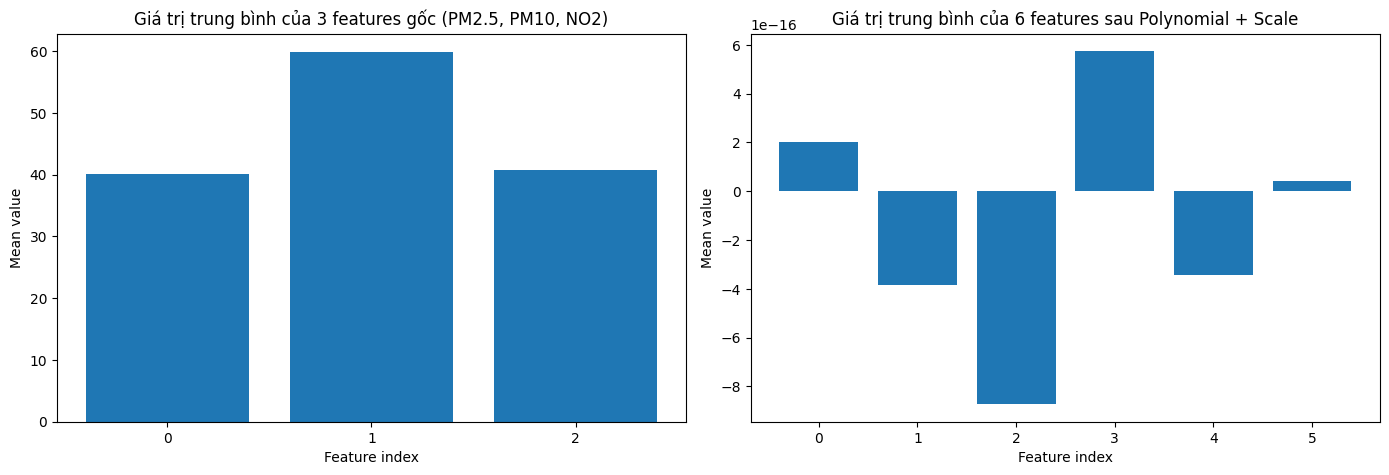

In [ ]:
# SS mean trước / sau scale (AQI)

mean_before = np.mean(X_train, axis=0)        # (3,)
mean_after  = np.mean(X_train_scaled, axis=0) # (6,)

plt.figure(figsize=(14, 5))

# Feature gốc (PM2.5, PM10, NO2)
plt.subplot(1, 2, 1)
plt.bar(range(len(mean_before)), mean_before)
plt.title("Giá trị trung bình của 3 features gốc (PM2.5, PM10, NO2)")
plt.xlabel("Feature index")
plt.ylabel("Mean value")
plt.xticks(range(len(mean_before)))

# Feature sau Polynomial + Scale
plt.subplot(1, 2, 2)
plt.bar(range(len(mean_after)), mean_after)
plt.title("Giá trị trung bình của 6 features sau Polynomial + Scale")
plt.xlabel("Feature index")
plt.ylabel("Mean value")
plt.xticks(range(len(mean_after)))

plt.tight_layout()
plt.show()


## Load dữ liệu
Hồi qui tuyến tính đơn giản là một cách tiếp cận để dự đoán phản ứng (giá trị đầu ra) khi dữ liệu có một đặc trưng duy nhất. Khi giả sử hai biến $x$ và $y$ liên hệ tuyến  tính thì mục tiêu của mô hình là cố tìm ra đường tuyến tính tốt nhất để dự đoán phản ứng ($y$).

Đường đó được gọi là đường hồi quy.

Công thức cho đường hồi quy được biểu diễn như sau:
$$ \hat{Y} = h(X) = XW+b$$
Trong đó:

- $X$ là ma trận có kích thước $N \times D$ với $X_{ij}$ là giá trị của đặc trưng thứ $j$ của mẫu $i$.
- $W$ là ma trận tham số có kích thước $D \times 1$
- $Y$ là giá trị phản ứng của $N$ mẫu.



## Huấn luyện mô hình

### Cập nhật tham số
Quá trình huấn luyện mô hình thực chất là từ dữ liệu để học ra tham số mô hình phù hợp nhất với mô hình sinh dữ liệu. Trong mô hình hồi quy tuyến tính, ta cần học tham số $W$.

Khi khởi tạo mô hình, ta giả sử tham số được khởi tạo ngẫu nhiên. Sử dụng tham số $W$ đó, ta ước lượng được giá trị $Y$:
$$ \hat{y} = h(X) = XW+b $$

Tổng sai số, độ lệch của giá trị dự đoán so với giá trị thực tế gọi là hàm giá trị (Cost function):
$$ J(w) = \frac{1}{2N}\sum_{i=1}^{N} (\hat{y}_i - y_i)^2 = \frac{1}{2N}\sum_{i=1}^{N}\sum_{j=1}^{D} (x_{ij}w_{i} - y_{ij})^2$$


Chúng ta sử thuật toán **xuống đồi (Gradient descent)** để tối ưu tham số $W$. (Xem khóa [Machine Learning](https://www.coursera.org/learn/machine-learning/))

Đột tụt dốc của tham số $W$ được cập nhật theo công thức:
$$ w_i = w_i -a.dw_i = w_i -a.\frac{\partial}{\partial w_i}J(w)$$

Đột tụt dốc của tham số $b$ được cập nhật theo công thức:
$$ b_i = b_i -a.db_i = b_i -a.\frac{\partial}{\partial b_i}J(b)$$

Trong đó đạo hàm của loss MSE theo W và b là:

$$ \frac{\partial J}{\partial w} = \frac{1}{N} \sum_{i=1}^N (\hat{y}_i - y_i)\cdot X_i$$
$$\frac{\partial J}{\partial b} = \frac{1}{N} \sum_{i=1}^N (\hat{y}_i - y_i)$$


In [ ]:
def linear_loss_vectorized(X, y, w, b):
    n = len(y)

    # Tính dự đoán: y_hat = Xw + b
    y_hat = np.dot(X, w) +b
    # Tính lỗi
    errors = y - y_hat

    # Tính loss (MSE)
    loss = np.mean(errors ** 2)

    # Tính gradient đối với w
    dw = -2 * np.dot(X.T, errors) / n

    # Tính gradient đối với b
    db = -2 * np.mean(errors)

    return loss, dw, db

In [ ]:
# Khởi tạo W theo đúng số feature sau scale
W = np.random.randn(X_test_scaled.shape[1], 1) * 0.0001

# Đảm bảo y là vector cột
y_test_vec = y_test.values.reshape(-1, 1)

loss, dw, db = linear_loss_vectorized(
    X_test_scaled,
    y_test_vec,
    W,
    0.0
)

print(f"Loss: {loss:.6f}")
print(f"Gradient of W shape: {dw.shape}")
print(f"Gradient of b: {db:.6f}")


Loss: 10383.563318
Gradient of W shape: (6, 1)
Gradient of b: -192.440115


### Huấn luyện với hàm cập nhật


Tham số W được cập nhật từng thành phần theo công thức:
$$ w_i =  w_i -\alpha\frac{\partial}{\partial w_i}J(w)$$

In [ ]:
class LinearRegression:
    def __init__(self):
        self.w = None
        self.b = None

    def train(self, X, y, learning_rate=0.01, num_iters=2000):
        n_samples, n_features = X.shape
        y = np.asarray(y).reshape(-1, 1)

        # Khởi tạo
        self.w = np.random.normal(0, 0.01, (n_features, 1))
        self.b = np.mean(y)

        loss_hist = []

        for it in range(num_iters):
            # Dự đoán
            y_hat = np.dot(X, self.w) + self.b
            errors = y_hat - y

            # Loss (MSE)
            loss = np.mean(errors ** 2)
            loss_hist.append(loss)

            # Gradient
            dw = np.dot(X.T, errors) / n_samples
            db = np.mean(errors)

            # Learning rate decay
            lr = learning_rate / (1 + 0.001 * it)

            # Update
            self.w -= lr * dw
            self.b -= lr * db

            if it % 200 == 0:
                print(f"Iteration {it}, Loss: {loss:.4f}")

        return loss_hist

    def predict(self, X):
        return np.dot(X, self.w) + self.b

    def evaluate(self, X_test, y_test):
        y_test = np.asarray(y_test).reshape(-1, 1)
        y_pred = self.predict(X_test)

        mse = mean_squared_error(y_test, y_pred)
        mae = mean_absolute_error(y_test, y_pred)
        r2  = r2_score(y_test, y_pred)

        return mse, mae, r2, y_pred


In [ ]:
print("\nHuấn luyện với X_train CHƯA scale (AQI)...")

model_raw = LinearRegression()
loss_raw = model_raw.train(
    X_train,
    y_train,
    learning_rate=1e-6,
    num_iters=2000
)



Huấn luyện với X_train CHƯA scale (AQI)...
Iteration 0, Loss: 1801.8517
Iteration 200, Loss: 1273.8331
Iteration 400, Loss: 1183.3146
Iteration 600, Loss: 1125.2473
Iteration 800, Loss: 1080.9576
Iteration 1000, Loss: 1045.8259
Iteration 1200, Loss: 1017.2746
Iteration 1400, Loss: 993.6230
Iteration 1600, Loss: 973.7176
Iteration 1800, Loss: 956.7396


In [ ]:
print("\nHuấn luyện với X_train ĐÃ scale (AQI)...")
model_scaled = LinearRegression()
loss_scaled = model_scaled.train(X_train_scaled, y_train, learning_rate=0.01, num_iters=2000)


Huấn luyện với X_train ĐÃ scale (AQI)...
Iteration 0, Loss: 1815.3948
Iteration 200, Loss: 217.2343
Iteration 400, Loss: 183.9527
Iteration 600, Loss: 162.2982
Iteration 800, Loss: 146.9103
Iteration 1000, Loss: 135.4843
Iteration 1200, Loss: 126.7185
Iteration 1400, Loss: 119.8139
Iteration 1600, Loss: 114.2552
Iteration 1800, Loss: 109.6964


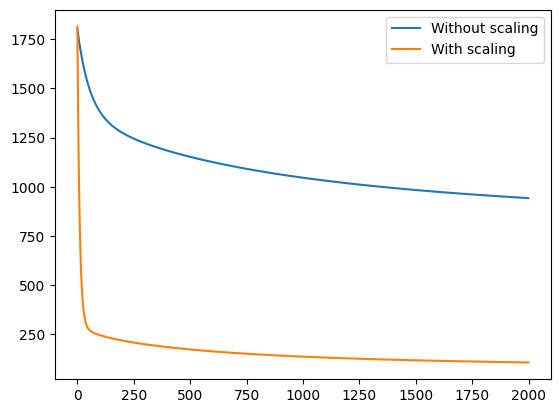

In [ ]:
plt.plot(loss_raw, label='Without scaling')
plt.plot(loss_scaled, label='With scaling')
plt.legend()
plt.show()


# Các chỉ số (thước đo) đánh giá mô hình hồi quy

## **Mean Squared Error (MSE) – Sai số bình phương trung bình**

- **Công thức**:  
 $$\text{MSE} = \frac{1}{n} \sum_{i=1}^n (y_i - \hat{y}_i)^2$$
- **Mục đích**:  
  Đo giá trị trung bình của bình phương sai lệch giữa giá trị dự đoán và giá trị thực tế, giúp nhấn mạnh các sai số lớn (sai số càng lớn thì mức phạt càng cao do bị bình phương).

## **Mean Absolute Error (MAE) – Sai số tuyệt đối trung bình**

- **Công thức**:  
  $$\text{MAE} = \frac{1}{n} \sum_{i=1}^n |y_i - \hat{y}_i|$$
- **Mục đích**:  
  Đo giá trị trung bình của độ lệch tuyệt đối giữa giá trị dự đoán và giá trị thực tế. Chỉ số này **ít bị ảnh hưởng bởi các giá trị ngoại lai (outliers)** so với MSE.

---

## **R-squared (R²) – Hệ số xác định**

- **Công thức**:  
 $$R^2 = 1 - \frac{\sum_{i=1}^n (y_i - \hat{y}_i)^2}{\sum_{i=1}^n (y_i - \bar{y})^2}$$
  trong đó  
  $$\bar{y} = \frac{1}{n} \sum_{i=1}^n y_i$$
  là **giá trị trung bình của các giá trị thực tế**.
- **Mục đích**:  
  Thể hiện **tỷ lệ phương sai của biến phụ thuộc được mô hình giải thích**, qua đó phản ánh **mức độ phù hợp (độ khớp)** của mô hình hồi quy.


In [ ]:
# đánh giá chất lượng mô hình trên tập
mse, mae, r2, y_pred = model_scaled.evaluate(X_test_scaled, y_test)

print("\nKết quả đánh giá mô hình dự đoán AQI:")
print(f"MSE : {mse:.4f}")
print(f"MAE : {mae:.4f} (sai trung bình ~ {mae:.1f} AQI)")
print(f"R²  : {r2:.4f}")
print(f"RMSE: {np.sqrt(mse):.4f}")



Kết quả đánh giá mô hình dự đoán AQI:
MSE : 97.0537
MAE : 7.6797 (sai trung bình ~ 7.7 AQI)
R²  : 0.9137
RMSE: 9.8516


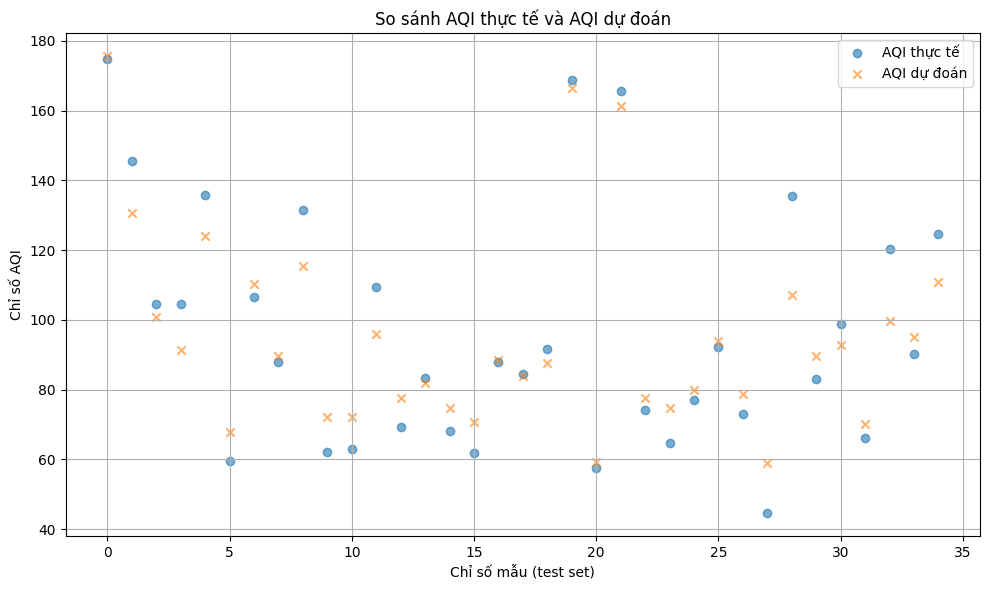

In [ ]:
plt.figure(figsize=(10, 6))

index = np.arange(len(y_test))  # chỉ số mẫu test

plt.scatter(index, y_test, alpha=0.6, label='AQI thực tế')
plt.scatter(index, y_pred, alpha=0.6, label='AQI dự đoán', marker='x')

plt.xlabel("Chỉ số mẫu (test set)")
plt.ylabel("Chỉ số AQI")
plt.title("So sánh AQI thực tế và AQI dự đoán")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


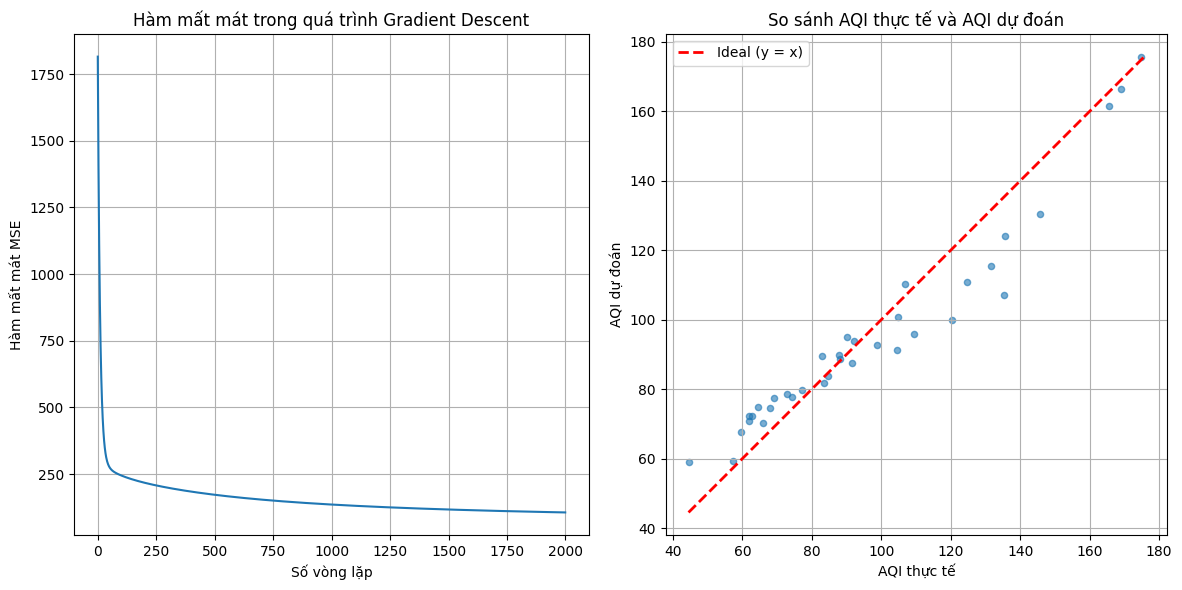

In [ ]:
# VISUALIZATION FOR AQI
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 6))

# Training loss
ax1.plot(loss_scaled)
ax1.set_xlabel("Số vòng lặp")
ax1.set_ylabel("Hàm mất mát MSE")
ax1.set_title("Hàm mất mát trong quá trình Gradient Descent")
ax1.grid(True)

# Actual vs Predicted AQI
y_test_flat = y_test
y_pred_flat = y_pred.flatten()

ax2.scatter(y_test_flat, y_pred_flat, alpha=0.6, s=20)

# Đường lý tưởng y = x
min_aqi = min(y_test_flat.min(), y_pred_flat.min())
max_aqi = max(y_test_flat.max(), y_pred_flat.max())
ax2.plot([min_aqi, max_aqi],
         [min_aqi, max_aqi],
         'r--', linewidth=2, label='Ideal (y = x)')

ax2.set_xlabel("AQI thực tế")
ax2.set_ylabel("AQI dự đoán")
ax2.set_title("So sánh AQI thực tế và AQI dự đoán")
ax2.legend()
ax2.grid(True)

# Giữ tỉ lệ 1:1
ax2.set_aspect('equal', adjustable='box')

plt.tight_layout()
plt.show()


DEMO


In [ ]:

def get_user_input_aqi():
    features = ['PM2.5', 'PM10', 'NO2']
    values = []

    for f in features:
        while True:
            try:
                v = float(input(f"Nhập {f}: "))
                if v < 0:
                    raise ValueError
                values.append(v)
                break
            except ValueError:
                print("Giá trị không hợp lệ, nhập lại.")

    return np.array(values).reshape(1, 3)

def predict_aqi_from_input(model, poly, scaler):
    X_new = get_user_input_aqi()

    # Polynomial
    X_new_poly = poly.transform(X_new)

    # Scale
    X_new_scaled = scaler.transform(X_new_poly)

    # Predict AQI
    y_pred = model.predict(X_new_scaled)

    print(f"\nAQI dự đoán: {y_pred[0][0]:.2f}")

predict_aqi_from_input(model_scaled, poly, scaler)


Nhập PM2.5: 100
Nhập PM10: 120
Nhập NO2: 33

AQI dự đoán: 159.92


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but PolynomialFeatures was fitted with feature names
  warnings.warn(
